# 04 — Model Selection & Hyperparameter Tuning

# Predicting Gallstone Disease from Clinical + Bioimpedance

**Domain:** Healthcare | **Task:** Binary Classification | **Data:** Tabular  
**Dataset:** `data/dataset-uci.csv`  
**Target column:** `Gallstone Status` (Yes[1]/No[0])

Run the cells top-to-bottom. These notebooks avoid seaborn per instructions and use pure matplotlib for charts.

## Objectives
- Cross-validated search over key models (LogReg, RF, XGBoost if available, SVM)
- Pick the best model by CV ROC-AUC
- Final evaluation on the untouched test set

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Load data (scaled splits from Notebook 02)
X_train = np.load("../data/processed/X_train_scaled.npy")
X_valid = np.load("../data/processed/X_valid_scaled.npy")
X_test  = np.load("../data/processed/X_test_scaled.npy")
y_train = np.load("../data/processed/y_train.npy")
y_valid = np.load("../data/processed/y_valid.npy")
y_test  = np.load("../data/processed/y_test.npy")

X_tr = np.vstack([X_train, X_valid])
y_tr = np.concatenate([y_train, y_valid])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_configs = []

# Logistic Regression
grid_configs.append((
    "LogisticRegression",
    LogisticRegression(max_iter=200, random_state=42),
    {"C":[0.01, 0.1, 1.0, 10.0], "penalty":["l2"]}
))

# Random Forest
grid_configs.append((
    "RandomForest",
    RandomForestClassifier(random_state=42),
    {"n_estimators":[200, 400, 800], "max_depth":[None, 4, 8, 16], "min_samples_split":[2, 5, 10]}
))

# SVC (probability=True for ROC-AUC)
grid_configs.append((
    "SVC",
    SVC(probability=True, random_state=42),
    {"C":[0.1,1,10], "kernel":["rbf","linear"], "gamma":["scale","auto"]}
))

grid_configs.append((
    "KNeighbors",
    KNeighborsClassifier(n_neighbors=5),
    {"n_neighbors":[3,5,7,9], "weights":["uniform","distance"]}
))

grid_configs.append((
    "DecisionTree",
    DecisionTreeClassifier(random_state=42),
    {"max_depth":[None, 4, 8, 16], "min_samples_split":[2, 5, 10]}
))

grid_configs.append((
    "GaussianNB",
    GaussianNB(),
    {"var_smoothing":[1e-9, 1e-8, 1e-7, 1e-6]}
))

cv_results = []
best_models = {}

for name, est, params in grid_configs:
    grid = GridSearchCV(
        estimator=est, param_grid=params, scoring="roc_auc",
        cv=cv, n_jobs=-1, verbose=1, refit=True
    )
    grid.fit(X_tr, y_tr)
    best_models[name] = grid.best_estimator_
    cv_results.append({
        "model": name,
        "best_params": grid.best_params_,
        "cv_best_score": grid.best_score_
    })

cv_df = pd.DataFrame(cv_results).sort_values("cv_best_score", ascending=False)
cv_df

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits


,model,best_params,cv_best_score
2,SVC,"{'C': 1, 'gamma': 'scale', 'kernel': 'linear'}",0.843918
1,RandomForest,"{'max_depth': 8, 'min_samples_split': 5, 'n_es...",0.842283
0,LogisticRegression,"{'C': 1.0, 'penalty': 'l2'}",0.814204
4,DecisionTree,"{'max_depth': 4, 'min_samples_split': 5}",0.730273
3,KNeighbors,"{'n_neighbors': 7, 'weights': 'distance'}",0.692049
5,GaussianNB,{'var_smoothing': 1e-06},0.683986


## Evaluate top CV model on the *test* set

Top model: SVC
Best params: {'C': 1, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'linear', 'max_iter': -1, 'probability': True, 'random_state': 42, 'shrinking': True, 'tol': 0.001, 'verbose': False}

Classification Report (Test):

              precision    recall  f1-score   support

No Gallstone       0.81      0.92      0.86        24
   Gallstone       0.90      0.79      0.84        24

    accuracy                           0.85        48
   macro avg       0.86      0.85      0.85        48
weighted avg       0.86      0.85      0.85        48



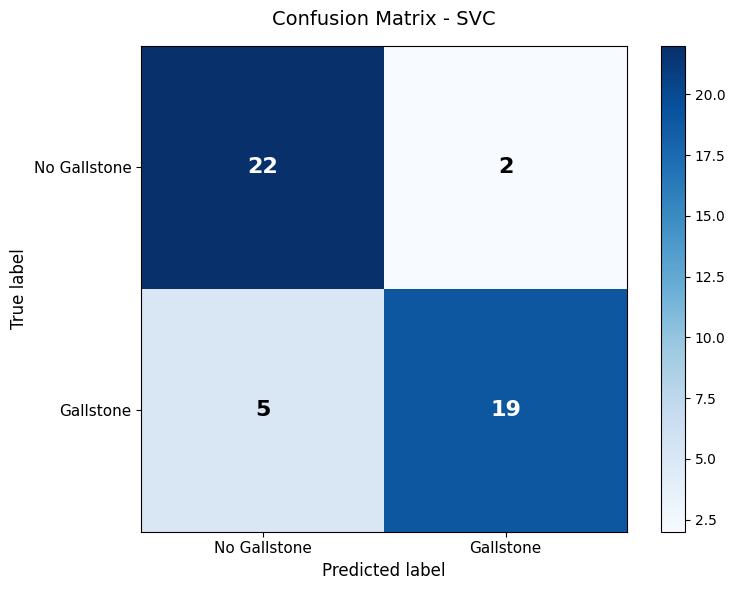

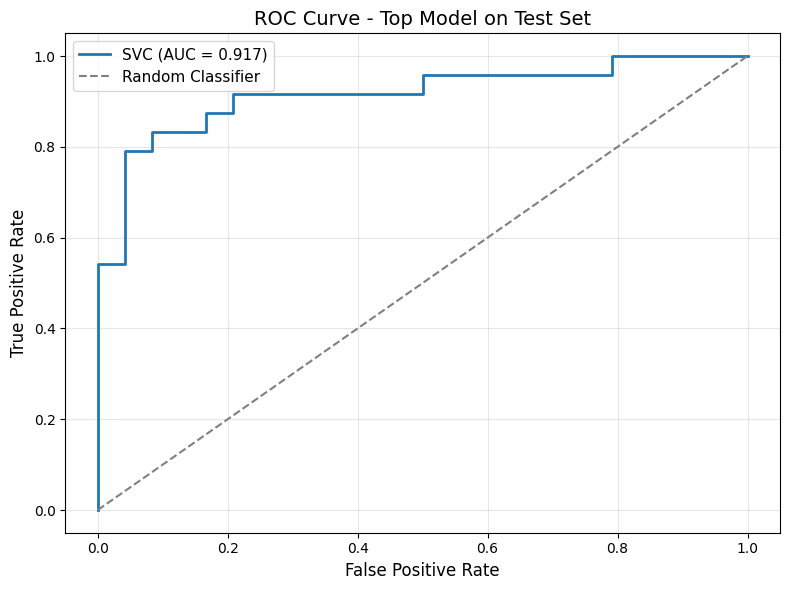


Test ROC-AUC: 0.9167


In [3]:
top_name = cv_df.iloc[0]["model"]
top_model = best_models[top_name]
print("Top model:", top_name)
print("Best params:", top_model.get_params())

y_pred = top_model.predict(X_test)
y_prob = top_model.predict_proba(X_test)[:,1]

print("\nClassification Report (Test):\n")
print(classification_report(y_test, y_pred, target_names=["No Gallstone", "Gallstone"]))

cm = confusion_matrix(y_test, y_pred)

# Create figure with proper labels
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap=plt.cm.Blues)

# Set ticks and labels
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["No Gallstone", "Gallstone"], fontsize=11)
ax.set_yticklabels(["No Gallstone", "Gallstone"], fontsize=11)

# Add labels
ax.set_xlabel("Predicted label", fontsize=12)
ax.set_ylabel("True label", fontsize=12)
ax.set_title(f"Confusion Matrix - {top_name}", fontsize=14, pad=15)

# Add values in cells
for i in range(2):
    for j in range(2):
        text = ax.text(j, i, str(cm[i, j]),
                      ha="center", va="center",
                      color="white" if cm[i, j] > cm.max() / 2 else "black",
                      fontsize=16, weight='bold')

# Add colorbar
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'{top_name} (AUC = {roc_auc_score(y_test, y_prob):.3f})', linewidth=2)
plt.plot([0,1],[0,1], linestyle="--", color='gray', label='Random Classifier')
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve - Top Model on Test Set", fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

test_auc = roc_auc_score(y_test, y_prob)
print(f"\nTest ROC-AUC: {test_auc:.4f}")